In [2]:
from myutils import cache, clean_all_cache, plot

from src import *
from glob import glob

from src.fisherinfo import FisherInformation, ApproxFisherInformation, FrequencyCFI

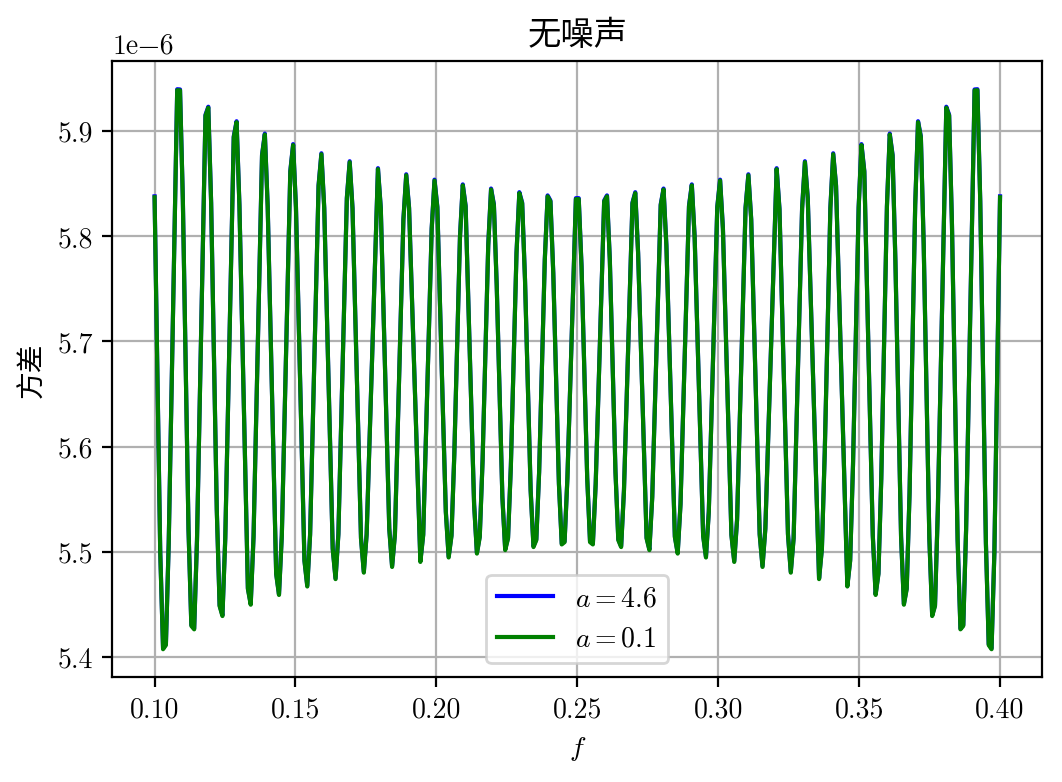

In [11]:
dicrb1 =  lambda f: 1 / FrequencyCFI(DI).cal(f, 5*DMD.PIXEL_SIZE/2, [1e-10, 4.6])
dicrb2 =  lambda f: 1 / FrequencyCFI(DI).cal(f, 5*DMD.PIXEL_SIZE/2, [1e-10, 0.1])

plot((0.1, 0.4), dicrb1, title='无噪声', label=r'$a = 4.6$')
plot((0.1, 0.4), dicrb2, label=r'$a = 0.1$', ylabel='方差', xlabel=r'$f$')

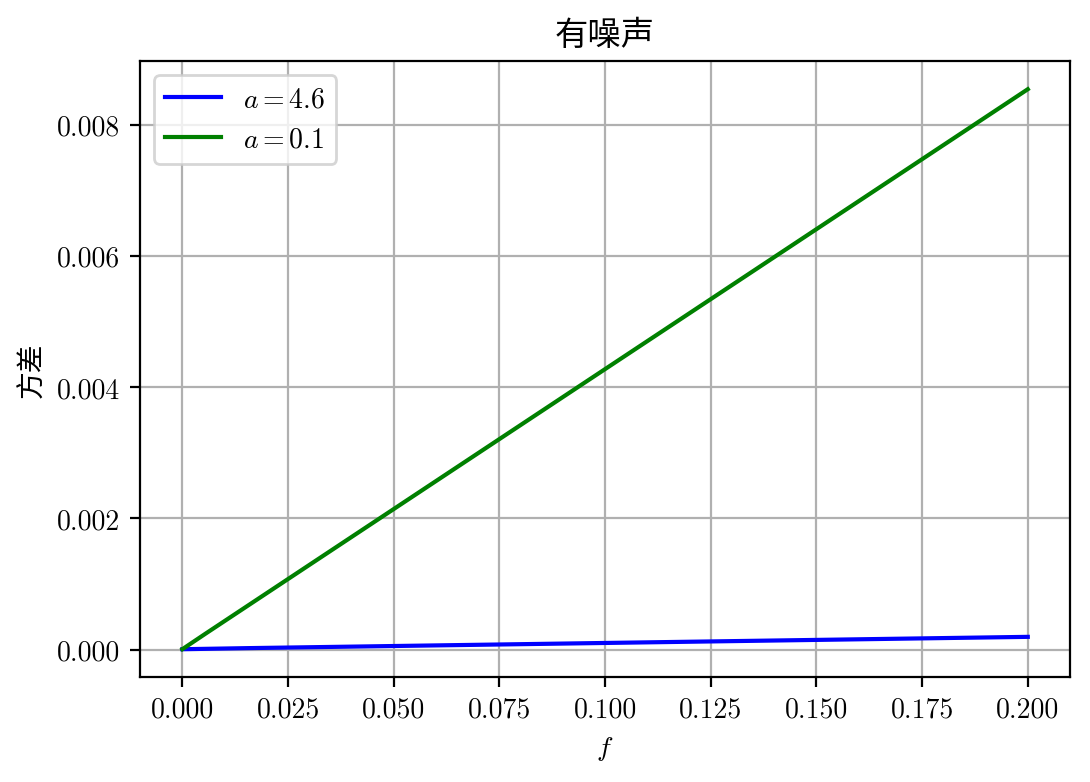

In [12]:
dicrb1 =  lambda b: 1 / FrequencyCFI(DI).cal(0.2, 5*DMD.PIXEL_SIZE/2, [b, 4.6])
dicrb2 =  lambda b: 1 / FrequencyCFI(DI).cal(0.2, 5*DMD.PIXEL_SIZE/2, [b, 0.1])
dicrb3 =  lambda b: 1 / FrequencyCFI(DI).cal(0.2, 5*DMD.PIXEL_SIZE/2, [b, 1e-10])

plot((1e-10, 0.2), dicrb1, title='有噪声', ylabel='方差', xlabel=r'$f$', label=r'$a = 4.6$')
plot((1e-10, 0.2), dicrb2, label=r'$a = 0.1$')

In [2]:
clean_all_cache()

done


0 NOISE

In [89]:
@cache
def read_est(A):
    file_tree = [
        f'__estimates__/0noise/spade_{A}px/*',
        f'__estimates__/0noise/di_{A}px/*'
    ]

    spade_x, spade_y = [], []
    di_x, di_y = [], []

    for file in file_tree:
        for f in glob(file):
            c = LoadEstimates(f) 
            if c.metadata.measurement == 'DI':
                di_x.append(c.metadata.ground_truth)
                di_y.append(c.estimates_a.var(ddof=0) * (c.photons.mean() - qCMOS.convert2photons(c.background.mean(), 0)))
            elif c.metadata.measurement == 'SPADE':
                spade_x.append(c.metadata.ground_truth)
                spade_y.append(c.estimates_a.var(ddof=0) * (c.photons.mean() - qCMOS.convert2photons(c.background.mean(), 0)))

    return np.array(di_x), np.array(di_y), np.array(spade_x), np.array(spade_y)

cache hit: reading result from cache file
cache hit: reading result from cache file


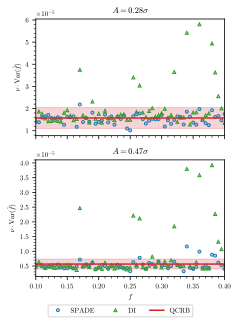

In [91]:
c1 = '#1f77b4'
c2 = '#2ca02c'

red = '#d62728'

width = 8.5 / 2.54 #inches

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

# factor = 1.31
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(width, width * 1.3), sharex=True)

for ax in (ax1, ax2):
    A = 3 if ax == ax1 else 5

    x_axis = np.linspace(0.1, 0.4, 1000)

    crb = list(1 / ApproxFisherInformation([A * DMD.PIXEL_SIZE / 2])) * 1000

    di_x, di_y, spade_x, spade_y = read_est(A)

    line1, = ax.plot(spade_x, spade_y, 
                    marker='o', linestyle='', markersize=3,
                    markeredgecolor=c1, markerfacecolor=(c1, 0.3))

    line2, = ax.plot(di_x, di_y,
                    marker='^', linestyle='', markersize=3,
                    markeredgecolor=c2, markerfacecolor=(c2, 0.3))

    line3, = ax.plot(x_axis, crb, red)
    # ax.plot(x_axis, 0.7 * crb, '-.', color=red)
    # ax.plot(x_axis, 1.3 * crb, '-.', color=red)

    # ax.grid(True, linestyle=':')

    ax.set_ylabel(r'$\nu\cdot{\rm Var}(\hat{f})$')
    ax.set_title(rf'$A = {np.round(A * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$')

    ax.fill_between(x_axis, 0.7 * np.array(crb), 1.3 * np.array(crb), color=red, alpha=0.2)

from matplotlib.ticker import AutoMinorLocator
for ax in (ax1, ax2):
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y')
    ax.set_xlim(0.1, 0.4)

    ax.set_box_aspect(0.618)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax2.set_xlabel(r'$f$')

fig.legend([line1, line2, line3], ['SPADE', 'DI', 'QCRB'], ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
plt.savefig('ideal.pdf')
plt.show()

NOISY

In [70]:
from scipy.interpolate import interp1d
from src.fisherinfo import FrequencyCFI

c_spade = LoadEstimates(rf'__estimates__\noisy\spade_5px\spade_5px_f0.2_d{0}.npz')
c_di = LoadEstimates(rf'__estimates__\noisy\di_5px\di_5px_f0.2_d{0}.npz')

spade_pn = c_spade.photons.mean() - qCMOS.convert2photons(c_spade.background, 0).mean()
di_pn = c_di.photons.mean() - qCMOS.convert2photons(c_di.background, 0).mean()


spade_f = [(LoadEstimates(rf'__estimates__\noisy\spade_5px\spade_5px_f0.2_d{d}.npz').estimates_a).var(ddof=1) * spade_pn for d in np.arange(0, 101, 2)]
di_f = [(LoadEstimates(rf'__estimates__\noisy\di_5px\di_5px_f0.2_d{d}.npz').estimates_a).var(ddof=1) * di_pn for d in np.arange(0, 101, 2)]

spade_b = [(LoadEstimates(rf'__estimates__\noisy\spade_5px\spade_5px_f0.2_d{d}.npz').background).mean() for d in np.arange(0, 101, 2)]
di_b = [(LoadEstimates(rf'__estimates__\noisy\di_5px\di_5px_f0.2_d{d}.npz').background).mean() for d in np.arange(0, 101, 2)]

spade_b = qCMOS.convert2photons(np.array(spade_b)) / spade_pn
di_b = qCMOS.convert2photons(np.array(di_b)) / di_pn


spade_interp = interp1d(spade_b, spade_f)
di_interp = interp1d(di_b, di_f)


dicfi =  lambda b: FrequencyCFI(DI).cal(0.2, 5*DMD.PIXEL_SIZE/2, [b, 4.6])
spadecfi =  lambda b: FrequencyCFI(BiSPADE).cal(0.2, 5*DMD.PIXEL_SIZE/2, [b])

b = np.linspace(1e-10, 0.1, 300)
ratio = np.array([dicfi(_b) / spadecfi(_b) for _b in b])

di_crb, spade_crb = 1/np.array([dicfi(_b) for _b in di_b]), 1/np.array([spadecfi(_b) for _b in spade_b])

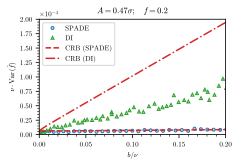

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, pi

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import AutoMinorLocator, ScalarFormatter


plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

b = np.linspace(0.01, 0.2, 300)
plt.figure(figsize=(8.5 / 2.54, 8.5 / 2.54))


plt.plot(spade_b, spade_f, color='#1f77b4', marker='o', 
         linestyle='', markersize=3, 
         markeredgecolor='#1f77b4', markerfacecolor=('#1f77b4', 0.3),
         label='SPADE')

plt.plot(di_b, di_f, color='#2ca02c', marker='^', 
         linestyle='', markersize=3, 
         markeredgecolor='#2ca02c', markerfacecolor=('#2ca02c', 0.3),
         label='DI')

plt.plot(spade_b, spade_crb, linestyle='--', color='#d62728', label='CRB (SPADE)')
plt.plot(di_b, di_crb, linestyle='-.', color='#d62728', label='CRB (DI)')


plt.xlabel(r'$b/\nu$')
plt.ylabel(r'$\nu\cdot{\rm Var\,}(\hat f)$')

plt.grid(False)
plt.legend(loc='best')

plt.gca().xaxis.set_minor_locator(AutoMinorLocator(5))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(5))


formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))

plt.gca().yaxis.set_major_formatter(formatter)
plt.xlim(0, 0.2)
plt.ylim(0, 2e-4)

plt.xticks(np.arange(0, 0.2001, 0.05))
#

plt.gca().set_box_aspect(0.618)

plt.title(r'$A=0.47\sigma;\quad f=0.2$')

plt.savefig('noisy.pdf')
plt.show()


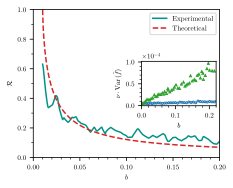

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, pi

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import AutoMinorLocator, ScalarFormatter


plt.rcParams['font.size'] = 7
b = np.linspace(0.01, 0.2, 300)
plt.figure(figsize=(8.5 / 2.54, 8.5 / 2.54 * 0.8))
plt.plot(b, spade_interp(b) / di_interp(b), color='#029386', label='Experimental')
plt.plot(b, ratio, '--', color='#d62728', label='Theoretical')

# plt.axhline(4.6 / (2*sqrt(pi)*103), c='#7f7f7f', linestyle='-.', label=r'$a/({2\sqrt{\pi}\sigma})$')

plt.xlabel(r'$b$')
plt.ylabel(r'$\mathcal {R}$')

plt.grid(False)
plt.legend(loc='best')
plt.xlim(0, 0.2)
plt.ylim(0, 1)
plt.xticks(np.arange(0, 0.2001, 0.05))

plt.gca().xaxis.set_minor_locator(AutoMinorLocator(5))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))


ax_inset = inset_axes(plt.gca(), width='40%', height='30%', loc='center right')
ax_inset.plot(spade_b, spade_f, color='#1f77b4', marker='o', linestyle='', markersize=2, markeredgecolor='#1f77b4', markerfacecolor=('#1f77b4', 0.3))
ax_inset.plot(di_b, di_f, color='#2ca02c', marker='^', linestyle='', markersize=2, markeredgecolor='#2ca02c', markerfacecolor=('#2ca02c', 0.3))
ax_inset.grid(False)
ax_inset.set_xlim(0, 0.22)

ax_inset.xaxis.set_minor_locator(AutoMinorLocator(5))
ax_inset.yaxis.set_minor_locator(AutoMinorLocator(5))

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))
ax_inset.xaxis.set_major_formatter(formatter)
ax_inset.yaxis.set_major_formatter(formatter)

ax_inset.set_ylabel(r'$\nu\cdot{\rm Var\,}(\hat f)$')
ax_inset.set_xlabel(r'$b$')
# plt.savefig('noisy.pdf')

plt.show()


SIMULATION

In [4]:
@cache
def read_est(A):
    file_tree = [
        f'__simulations__/0noise_sign/spade_{A}px/*',
        f'__simulations__/0noise_sign/di_{A}px/*'
    ]

    spade_x, spade_y = [], []
    di_x, di_y = [], []

    for file in file_tree:
        for f in glob(file):
            c = LoadEstimates(f) 
            if c.metadata.measurement == 'DI':
                di_x.append(c.metadata.ground_truth)
                di_y.append(c.estimates_a.var(ddof=0) * (c.photons.mean() - qCMOS.convert2photons(c.background.mean(), 0)))
            elif c.metadata.measurement == 'SPADE':
                spade_x.append(c.metadata.ground_truth)
                spade_y.append(c.estimates_a.var(ddof=0) * (c.photons.mean() - qCMOS.convert2photons(c.background.mean(), 0)))

    return np.array(di_x), np.array(di_y), np.array(spade_x), np.array(spade_y)

cache hit: reading result from cache file
cache hit: reading result from cache file


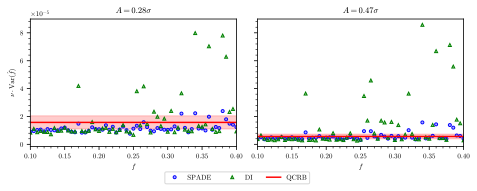

In [8]:
c1 = 'b'
c2 = 'g'

red = 'r'

width = 8.5

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(width / 2.54 * 2, width / 2.54 * 1.4 / 2), sharey=True)

for ax in (ax1, ax2):
    A = 3 if ax == ax1 else 5

    x_axis = np.linspace(0.1, 0.4, 1000)

    crb = list(1 / ApproxFisherInformation([A * DMD.PIXEL_SIZE / 2])) * 1000

    di_x, di_y, spade_x, spade_y = read_est(A)

    line1, = ax.plot(spade_x, spade_y, 
                    marker='o', linestyle='', markersize=3,
                    markeredgecolor=c1, markerfacecolor=(c1, 0.3))

    line2, = ax.plot(di_x, di_y,
                    marker='^', linestyle='', markersize=3,
                    markeredgecolor=c2, markerfacecolor=(c2, 0.3))

    line3, = ax.plot(x_axis, crb, red)
    # ax.plot(x_axis, 0.7 * crb, '-.', color=red)
    # ax.plot(x_axis, 1.3 * crb, '-.', color=red)

    # ax.grid(True, linestyle=':')

    
    ax.set_title(rf'$A = {np.round(A * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$')

    ax.fill_between(x_axis, 0.7 * np.array(crb), 1.3 * np.array(crb), color=red, alpha=0.2)

from matplotlib.ticker import AutoMinorLocator
for ax in (ax1, ax2):
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y')
    ax.set_xlim(0.1, 0.4)

    ax.set_box_aspect(0.618)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    
ax1.set_ylabel(r'$\nu\cdot{\rm Var}(\hat{f})$')
ax1.set_xlabel(r'$f$')
ax2.set_xlabel(r'$f$')

fig.legend([line1, line2, line3], ['SPADE', 'DI', 'QCRB'], ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig('ideal_sim.pdf')
plt.show()

SIMULATION NO DELAY

In [9]:
@cache
def read_est(wave):
    file_tree = [
        f'__simulations__/{wave}/*',
        # f'__simulations__/{wave}/*'
    ]

    spade_x, spade_y = [], []
    di_x, di_y = [], []

    for file in file_tree:
        for f in glob(file):
            c = LoadEstimates(f) 
            if c.metadata.measurement == 'DI':
                di_x.append(c.metadata.ground_truth)
                di_y.append(c.estimates_a.var(ddof=0) * (c.photons.mean() - qCMOS.convert2photons(c.background.mean(), 0)))
            elif c.metadata.measurement == 'SPADE':
                spade_x.append(c.metadata.ground_truth)
                spade_y.append(c.estimates_a.var(ddof=0) * (c.photons.mean() - qCMOS.convert2photons(c.background.mean(), 0)))

    return np.array(di_x), np.array(di_y), np.array(spade_x), np.array(spade_y)

cache hit: reading result from cache file
cache hit: reading result from cache file


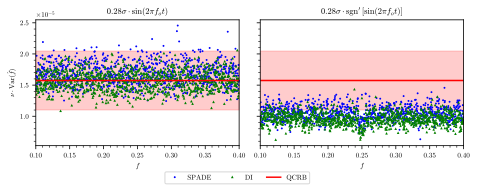

In [19]:
c1 = 'b'
c2 = 'g'

red = 'r'

width = 8.5

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(width / 2.54 * 2, width / 2.54 * 1.4 / 2), sharey=True)

for ax in (ax1, ax2):
    A = 3
    wave = 'sin' if ax == ax1 else 'sign'

    x_axis = np.linspace(0.1, 0.4, 1000)

    crb = list(1 / ApproxFisherInformation([A * DMD.PIXEL_SIZE / 2])) * 1000

    di_x, di_y, spade_x, spade_y = read_est(wave)

    line1, = ax.plot(spade_x, spade_y, 
                    marker='o', linestyle='', markersize=1,
                    markeredgecolor=c1)

    line2, = ax.plot(di_x, di_y,
                    marker='^', linestyle='', markersize=1,
                    markeredgecolor=c2)

    line3, = ax.plot(x_axis, crb, red)
    # ax.plot(x_axis, 0.7 * crb, '-.', color=red)
    # ax.plot(x_axis, 1.3 * crb, '-.', color=red)

    # ax.grid(True, linestyle=':')

    
    # ax.set_title(rf'$A = {np.round(A * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$')

    ax.fill_between(x_axis, 0.7 * np.array(crb), 1.3 * np.array(crb), color=red, alpha=0.2)

from matplotlib.ticker import AutoMinorLocator
for ax in (ax1, ax2):
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y')
    ax.set_xlim(0.1, 0.4)

    ax.set_box_aspect(0.618)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    
ax1.set_ylabel(r'$\nu\cdot{\rm Var}(\hat{f})$')
ax1.set_xlabel(r'$f$')
ax2.set_xlabel(r'$f$')

ax1.set_title(r'$0.28\sigma\cdot\sin(2\pi f_o t)$')
ax2.set_title(r"$0.28\sigma\cdot{\rm sgn'\,}[\sin(2\pi f_o t)]$")

fig.legend([line1, line2, line3], ['SPADE', 'DI', 'QCRB'], ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig('0delay(sim).pdf')
plt.show()